# YOLO End-to-End: African Wildlife Detection (k)

## What we're building

We'll train a YOLO detector to find and classify four African wildlife species — **buffalo, elephant, rhino, and zebra** — in photographs. This has a real-world use case (wildlife conservation, anti-poaching camera traps, safari tourism), but more importantly it's a dataset designed specifically for teaching.

## Why this dataset

- **Tiny (100 MB)** — downloads in under a minute on any internet connection.
- **Auto-downloads with zero setup** — no API keys, no signup, no Kaggle auth. Just run the cell and the Ultralytics package fetches it from a public GitHub release.
- **Well-curated**: 1504 images total (1052 train / 225 val / 227 test), already in perfect YOLO format.
- **Only 4 classes** — can see clear patterns in per-class performance.
- **Real photos from real safari cameras** — we're not training on toy data.

## Learning objectives

By the end of this notebook, you will have:

1. Loaded and **inspected** a real detection dataset (not just downloaded it blindly).
2. **Understood the YOLO label format** by reading actual label files and converting them back to pixels.
3. Spotted **class imbalance** in the training data and predicted how it will affect the model.
4. **Fine-tuned** a COCO-pretrained YOLO model — and we'll explain exactly what "fine-tuning" means here, layer by layer.
5. **Read training curves** like a mechanic reads a car diagnostic — each line tells you something specific.
6. Computed and **interpreted** mAP, per-class AP, precision, and recall.
7. Run **inference** and wrapped the model in a tiny "wildlife alert" function.
8. **Exported to ONNX** for deployment and validated the export works.

## What you should already know

- You've trained a CNN classifier before (MNIST, CIFAR — anything).
- You know what softmax, cross-entropy, and backpropagation are.
- You understand transfer learning at a conceptual level.

## Hardware requirements

- **Google Colab (free T4 GPU)**: ~15-20 min for 30 epochs. Recommended.
- **Any local machine with an NVIDIA GPU**: similar speed.
- **CPU-only laptop**: works, will be slow (~1.5 hrs for 30 epochs). We auto-detect and scale down the workload so it's still tractable.

---
## Section 1: Environment Setup

One package does all the heavy lifting: **`ultralytics`**. It bundles the YOLO model code, a training loop, a dataloader, data augmentation, evaluation metrics, ONNX export, and (conveniently for us) a dataset auto-downloader.

We'll also bring in the standard DS stack for our own exploration (pandas, matplotlib, PIL).

In [ ]:
# Install dependencies.
# `-q` keeps output clean. In a production env, version-pin these in a requirements.txt.
%pip install -q "ultralytics>=8.2.0" matplotlib pandas Pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 47.2 MB/s eta 0:00:00


In [ ]:
# Do ALL imports up-front. This is a best practice because:
# 1. It makes the notebook's dependencies obvious at a glance.
# 2. If any import is going to fail, it fails early (not 30 minutes into training).
# 3. A reader skimming the notebook can see the tech stack in one cell.

import os
import glob
import random
import shutil
import yaml
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.image as mpimg
from PIL import Image

import torch
from ultralytics import YOLO

# --- Reproducibility ---
# Setting seeds everywhere we can. Object detection training is not *fully* deterministic
# on GPU (CUDA kernels, dataloader worker shuffling, mosaic augmentation randomness), but
# setting seeds gets us ~95% reproducible runs, which is enough for teaching.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# --- Hardware check ---
# Always print this at the top of a notebook. You'd be shocked how many 'training is slow'
# bug reports turn out to be 'oh, I wasn't actually using the GPU.'
print(f"PyTorch version:  {torch.__version__}")
print(f"CUDA available:   {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:              {torch.cuda.get_device_name(0)}")
    gpu_mem_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU memory:       {gpu_mem_gb:.1f} GB")
else:
    print("No GPU detected. Training will run on CPU (slower but still works).")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch version:  2.10.0+cu128
CUDA available:   True
GPU:              Tesla T4
GPU memory:       15.6 GB


---
## Section 2: The Dataset — Download and Inspect

Here's the magic of Ultralytics: **we don't need to download the dataset ourselves.** When we pass `data='african-wildlife.yaml'` to `model.train()`, the library:

1. Looks for a local `african-wildlife/` folder.
2. If not found, downloads a zip from the public URL specified in the YAML config (`https://github.com/ultralytics/assets/releases/download/v0.0.0/african-wildlife.zip`, about 100 MB).
3. Extracts it, verifies structure, and starts training.

### About the dataset

- **Source:** Ultralytics 
- **Classes (4):** buffalo, elephant, rhino, zebra — all large African mammals, photographed in reserves.
- **Splits:** 1052 train / 225 validation / 227 test = 1504 total images.
- **Size:** ~100 MB zipped, ~150 MB extracted.
- **Format:** standard YOLO (images + .txt label files + data.yaml).


In [ ]:
# Import the dataset download helper.
from ultralytics.utils.downloads import safe_download
from ultralytics import settings

# Ultralytics keeps a configurable 'datasets' directory. By default on Colab it's ~/datasets,
# on local machines it's usually in your home folder. Let's see where it will go:
datasets_dir = Path(settings['datasets_dir'])
print(f"Datasets will be stored at: {datasets_dir}")

# The dataset URL (from the african-wildlife.yaml config, publicly documented)
DATASET_URL = "https://github.com/ultralytics/assets/releases/download/v0.0.0/african-wildlife.zip"
DATASET_DIR = datasets_dir / "african-wildlife"

# Only download if not already present — re-running this cell is a no-op after the first time.
if not DATASET_DIR.exists():
    print(f"Downloading African Wildlife dataset (~100 MB) from:\n  {DATASET_URL}")
    datasets_dir.mkdir(parents=True, exist_ok=True)
    # safe_download handles retries, progress bars, and auto-unzipping.
    safe_download(url=DATASET_URL, dir=datasets_dir, unzip=True, delete=True)
    print("Download complete.")
else:
    print(f"Dataset already exists at {DATASET_DIR} — skipping download.")

# Sanity check: what's inside?
print("\nTop-level contents of the dataset directory:")
for item in sorted(DATASET_DIR.iterdir()):
    size_mb = sum(f.stat().st_size for f in item.rglob('*') if f.is_file()) / 1e6 if item.is_dir() else item.stat().st_size / 1e6
    print(f"  {item.name:<20s} ({size_mb:.1f} MB)")

Datasets will be stored at: /content/datasets
  https://github.com/ultralytics/assets/releases/download/v0.0.0/african-wildlife.zip
Unzipping /content/datasets/african-wildlife.zip to /content/datasets/african-wildlife...: 100% ━━━━━━━━━━━━ 3018/3018 3.8Kfiles/s 0.8s
Download complete.

Top-level contents of the dataset directory:
  LICENSE.txt          (0.0 MB)
  african-wildlife.yaml (0.0 MB)
  images               (104.8 MB)
  labels               (0.1 MB)


In [ ]:
# You should see something like:
#   train/    (images + labels)
#   val/    (images + labels)
#   test/     (images + labels)
#
# This is the standard YOLO layout. Let's verify each split has BOTH images and labels,
# and count them. This is mostly to teach you the structure to expect.
for split in ['train', 'val', 'test']:
    img_dir = DATASET_DIR /'images' / split
    lbl_dir = DATASET_DIR /'labels' /split
    if img_dir.exists() and lbl_dir.exists():
        n_imgs = len(list(img_dir.glob('*.jpg'))) + len(list(img_dir.glob('*.png')))
        n_lbls = len(list(lbl_dir.glob('*.txt')))
        print(f"  {split:6s}: {n_imgs:5d} images, {n_lbls:5d} labels")
    else:
        print(f"  {split:6s}: MISSING (expected {img_dir} and {lbl_dir})")

# RULE: in a correctly formed YOLO dataset, n_images should equal n_labels.
# If they don't match, you have either (a) images missing labels, or (b) orphan labels
# from a prior run. Both cause silent training bugs. Check this always.

  train :  1049 images,  1052 labels
  val   :   225 images,   225 labels
  test  :   227 images,   227 labels


---
## Section 3: Understanding `data.yaml` — the Detection Dataset Manifest

Every YOLO dataset is described by a small YAML file. Think of it as the dataset's **manifest** or **table of contents**: it tells the training code where the images live, where the labels live, and what each class ID maps to.

### Why YAML and not JSON or a Python config?

YAML is human-friendly, supports comments, and is the standard across the ML ecosystem (PyTorch Lightning, Hydra, Kubernetes all use it). If you've never worked with YAML — it's just a structured text format. Keys and values, indented to show hierarchy.

### The fields that matter

```yaml
path: /absolute/path/to/dataset   # dataset root
train: train/images              # where training images live (relative to path)
val:   valid/images              # where validation images live
test:  test/images               # where test images live (optional)
names:                           # class_id -> class_name mapping
  0: buffalo
  1: elephant
  2: rhino
  3: zebra
```

The training code resolves image paths as `path + train + image_name`, and then finds the label by replacing `/images/` with `/labels/` and `.jpg` with `.txt`. That's the whole convention.

### The Ultralytics-provided `african-wildlife.yaml`

Ultralytics ships a yaml for this dataset inside the package. Let's read it.

In [ ]:
# The yaml ships with the package. Find it:
import ultralytics

PACKAGE_YAML = Path(ultralytics.__file__).parent / 'cfg' / 'datasets' / 'african-wildlife.yaml'
print(f"Packaged YAML location: {PACKAGE_YAML}\n")

with open(PACKAGE_YAML) as f:
    data_cfg = yaml.safe_load(f)

print("Contents:")
print("-" * 50)
for k, v in data_cfg.items():
    print(f"{k}: {v}")
print("-" * 50)

# The 'path' in the shipped yaml is relative. We'll write our own yaml with an absolute
# path pointing to our downloaded location — this prevents 'can't find images' bugs when
# running from different working directories.
data_cfg['path'] = str(DATASET_DIR.resolve())
# The ultralytics yaml uses 'valid/images' as the val folder — mirror that exactly.
data_cfg['train'] = 'images/train'
data_cfg['val'] = 'images/val'
data_cfg['test'] = 'images/test'
# Remove the download URL so it doesn't re-download on every run
data_cfg.pop('download', None)

# Save our corrected yaml in the working directory.
LOCAL_YAML = Path('african-wildlife-local.yaml')
with open(LOCAL_YAML, 'w') as f:
    yaml.safe_dump(data_cfg, f, sort_keys=False)

print(f"\nWrote local yaml -> {LOCAL_YAML.resolve()}")
print(f"\nClass count (nc): {len(data_cfg['names'])}")
print(f"Class names: {data_cfg['names']}")

# Set class names as a dict keyed by int, so we can index with a class_id directly
CLASS_NAMES = data_cfg['names']
if isinstance(CLASS_NAMES, list):
    CLASS_NAMES = {i: n for i, n in enumerate(CLASS_NAMES)}

Packaged YAML location: /usr/local/lib/python3.12/dist-packages/ultralytics/cfg/datasets/african-wildlife.yaml

Contents:
--------------------------------------------------
path: african-wildlife
train: images/train
val: images/val
test: images/test
names: {0: 'buffalo', 1: 'elephant', 2: 'rhino', 3: 'zebra'}
download: https://github.com/ultralytics/assets/releases/download/v0.0.0/african-wildlife.zip
--------------------------------------------------

Wrote local yaml -> /content/african-wildlife-local.yaml

Class count (nc): 4
Class names: {0: 'buffalo', 1: 'elephant', 2: 'rhino', 3: 'zebra'}


---
## Section 4: Reading Label Files 

each line of a label file is one object. Format is `<class_id> <x_center> <y_center> <width> <height>`, all coordinates normalized to [0, 1]. To get pixel coordinates, multiply x-values by image width and y-values by image height.

In [ ]:
# Grab paths to all training images and labels
train_images_dir = DATASET_DIR / 'images'/ 'train'
train_labels_dir = DATASET_DIR / 'labels' / 'train'

train_images = sorted(glob.glob(str(train_images_dir / '*.jpg'))) + \
               sorted(glob.glob(str(train_images_dir / '*.png')))
train_labels = sorted(glob.glob(str(train_labels_dir / '*.txt')))

val_images_dir = DATASET_DIR / 'images'/'val'
val_labels_dir = DATASET_DIR / 'labels'/ 'val'
val_images = sorted(glob.glob(str(val_images_dir / '*.jpg'))) + \
             sorted(glob.glob(str(val_images_dir / '*.png')))

print(f"Training images: {len(train_images)}")
print(f"Training labels: {len(train_labels)}")
print(f"Validation images: {len(val_images)}")

# integrity check: every image should have a corresponding label file.
# (An empty label file means 'no objects in this image' — that's valid. But MISSING is bad.)
img_stems = {Path(p).stem for p in train_images}
lbl_stems = {Path(p).stem for p in train_labels}
missing = img_stems - lbl_stems
orphan = lbl_stems - img_stems
print(f"\nImages missing their label file: {len(missing)}")
print(f"Label files with no matching image: {len(orphan)}")
# In a clean dataset, both should be zero.

Training images: 1049
Training labels: 1052
Validation images: 225

Images missing their label file: 0
Label files with no matching image: 3


Image:      2 (4).jpg
Dimensions: 640 x 480 pixels

Label file: /content/datasets/african-wildlife/labels/train/2 (4).txt

--- Raw contents ---
1 0.363281 0.664583 0.373437 0.412500
1 0.573438 0.657292 0.312500 0.360417

--- Decoded (normalized -> pixels) ---
Line  Class       cx_norm   cy_norm   w_norm    h_norm    box_pixels                    
------------------------------------------------------------------------------------------
0     elephant    0.3633    0.6646    0.3734    0.4125    (113,219)→(351,417)
1     elephant    0.5734    0.6573    0.3125    0.3604    (267,229)→(467,402)


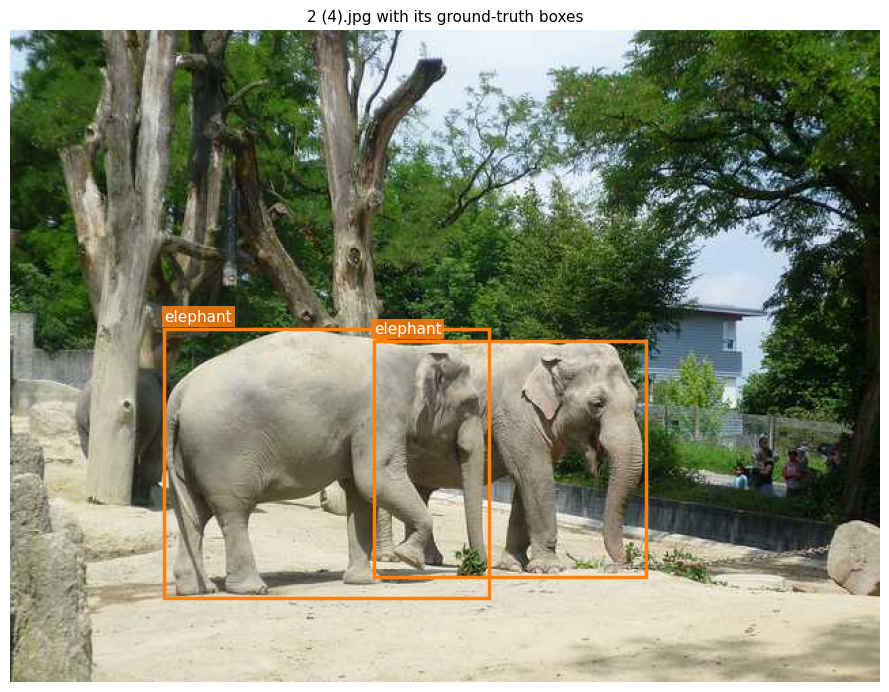

In [ ]:
# Pick a random label file and read it with our eyes.
# Setting a seed here so the notebook is reproducible.
random.seed(3)
sample_label_path = random.choice(train_labels)

# Construct the corresponding image path by swapping the extension
sample_image_path = train_images_dir / f"{Path(sample_label_path).stem}.jpg"

# Open image to get dimensions; YOLO labels are relative to these
with Image.open(sample_image_path) as img:
    img_w, img_h = img.size

print(f"Image:      {sample_image_path.name}")
print(f"Dimensions: {img_w} x {img_h} pixels")
print(f"\nLabel file: {sample_label_path}")
print("\n--- Raw contents ---")
with open(sample_label_path) as f:
    raw_contents = f.read()
print(raw_contents)

print("--- Decoded (normalized -> pixels) ---")
print(f"{'Line':<6}{'Class':<12}{'cx_norm':<10}{'cy_norm':<10}{'w_norm':<10}{'h_norm':<10}{'box_pixels':<30}")
print("-" * 90)

# Iterate through each line in the YOLO label file
for i, line in enumerate(raw_contents.strip().split('\n')):
    parts = line.split()
    cls_id = int(parts[0])
    cx, cy, w, h = map(float, parts[1:5])

    # YOLO format is [center_x, center_y, width, height] normalized (0 to 1)
    # To get pixel coordinates for a bounding box (x1, y1) to (x2, y2):
    x1 = int((cx - w/2) * img_w)
    y1 = int((cy - h/2) * img_h)
    x2 = int((cx + w/2) * img_w)
    y2 = int((cy + h/2) * img_h)

    print(f"{i:<6}{CLASS_NAMES[cls_id]:<12}{cx:<10.4f}{cy:<10.4f}{w:<10.4f}{h:<10.4f}"
          f"({x1},{y1})→({x2},{y2})")

# --- Visualization ---
fig, ax = plt.subplots(1, 1, figsize=(9, 7))
ax.imshow(Image.open(sample_image_path))

for line in raw_contents.strip().split('\n'):
    parts = line.split()
    cls_id = int(parts[0])
    cx, cy, w, h = map(float, parts[1:5])

    # Calculate corner coordinates and dimensions for Matplotlib Rectangle
    x1 = (cx - w/2) * img_w
    y1 = (cy - h/2) * img_h
    box_w_px = w * img_w
    box_h_px = h * img_h

    # Use a consistent color for each class using a colormap
    color = plt.cm.tab10(cls_id)

    # Add the bounding box outline
    rect = patches.Rectangle((x1, y1), box_w_px, box_h_px,
                             linewidth=2.5, edgecolor=color, facecolor='none')
    ax.add_patch(rect)

    # Add a text label above the box:
    # - Positioned at (x1, y1) with a small vertical offset (-6) to stay clear of the box edge
    # - Uses a background 'bbox' (bounding box for the text) for readability
    # - pad=2 adds internal spacing, alpha=0.85 makes it slightly transparent
    ax.text(x1, y1 - 6, CLASS_NAMES[cls_id], fontsize=11, color='white',
            bbox=dict(facecolor=color, alpha=0.85, pad=2, edgecolor='none'))

ax.set_title(f"{sample_image_path.name} with its ground-truth boxes", fontsize=11)
ax.axis('off')
plt.tight_layout()
plt.show()

 The two things on your screen should now match:
- The numbers we printed (normalized coordinates)
- The boxes on the image (pixel coordinates)

They're the same information in different units. The *label* is just numbers in a text file. The *image* with the boxes drawn on it is something we built in Python — YOLO never sees it. During training, YOLO consumes the raw label file, does its own math, and learns to produce similar numbers on new images.

If you ever get confused during debugging, come back to this: **the labels are just numbers in text files. That's all they are.**

---
## Section 5: Visualizing a Batch — What Will the Model See?

One random image is not enough. Let's plot a 3x3 grid to get a feel for the dataset. Look for:
- **Image quality**: lighting, focus, angles.
- **Box tightness**: good labels wrap objects snugly. Loose boxes = weaker training signal.
- **Object sizes**: some tiny? Some huge? Mix matters for what model size we need.
- **Occlusion and clutter**: are there partially hidden animals, other animals in frame, humans?



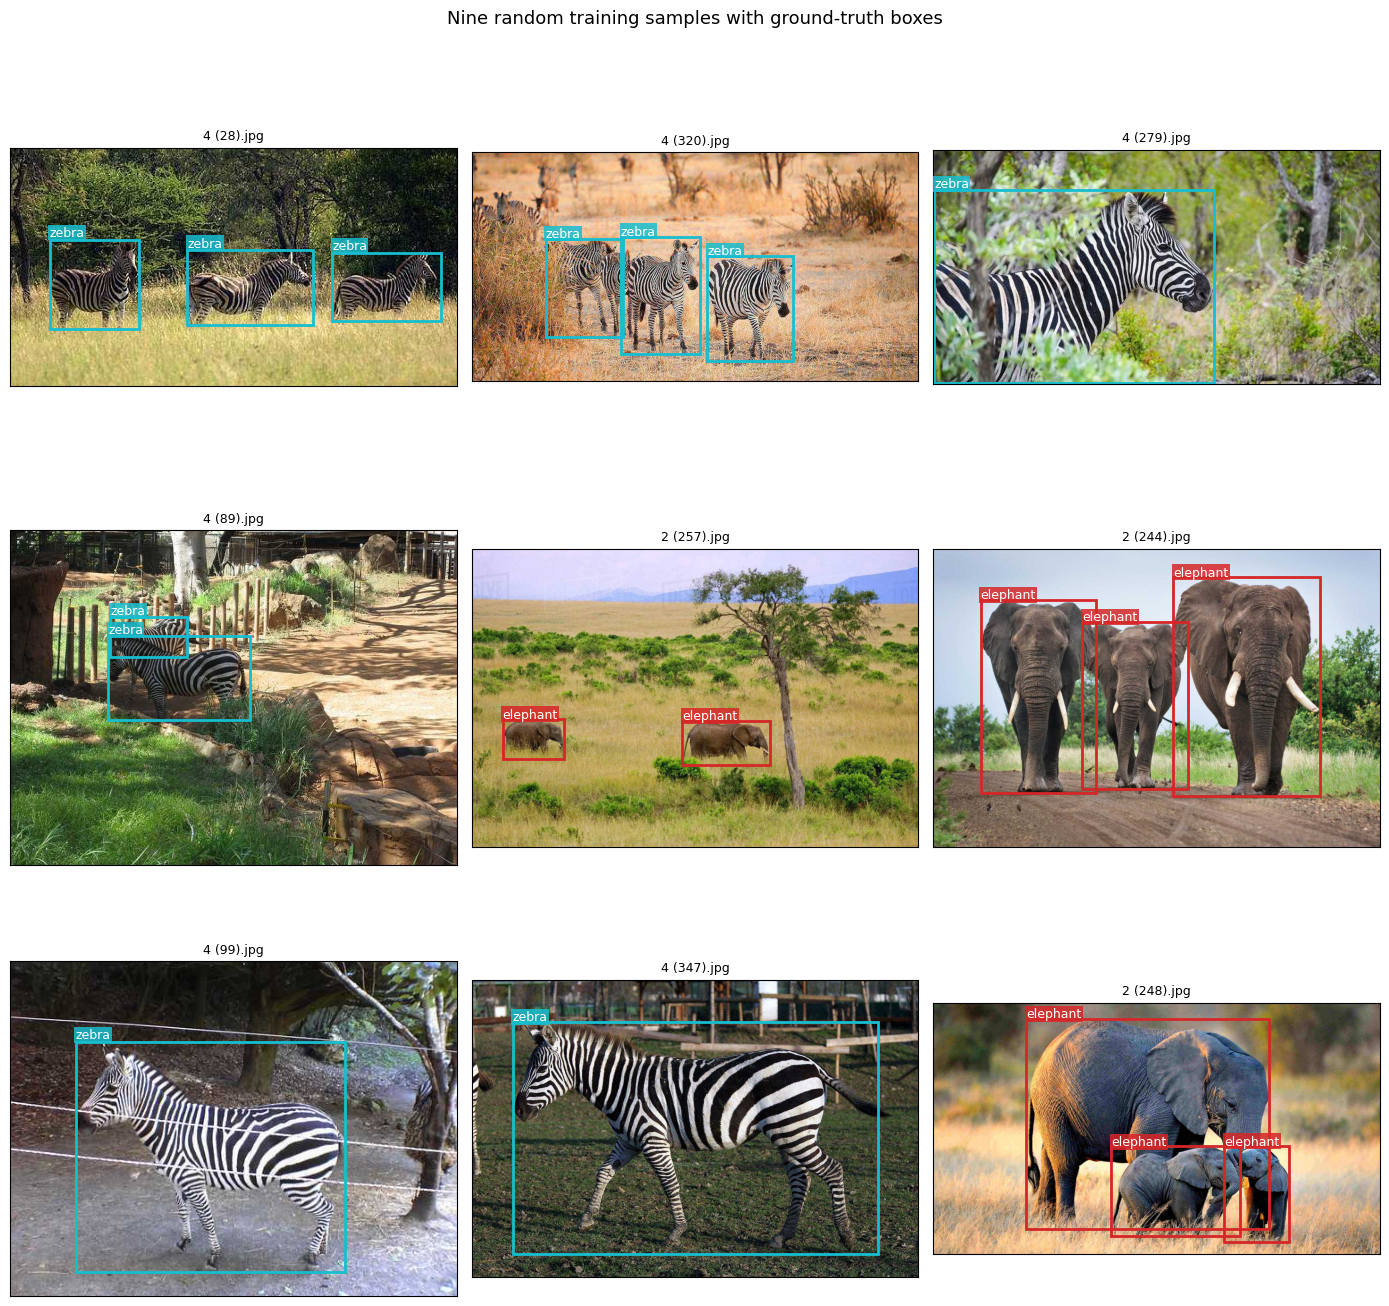

In [ ]:
def draw_yolo_boxes(image_path, label_path, class_names, ax):
    """Draw YOLO-format boxes from a label file onto an image.

    This is the same conversion logic as above, packaged into a reusable function.
    If a label file is missing or empty, that's fine — just draws the image.
    """
    img = Image.open(image_path).convert('RGB')
    W, H = img.size
    ax.imshow(img)
    # Hide axes for a cleaner grid view
    ax.set_xticks([])
    ax.set_yticks([])
    # Generate a unique color for each class in the legend
    colors = plt.cm.tab10(np.linspace(0, 1, len(class_names)))

    if Path(label_path).exists():
        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                cid = int(parts[0])
                cx, cy, w, h = map(float, parts[1:5])
                # Convert normalized [0,1] to pixel coordinates
                x1, y1 = (cx - w/2) * W, (cy - h/2) * H
                box_w, box_h = w * W, h * H
                # Create Rectangle patch and add to the specific subplot axis
                rect = patches.Rectangle((x1, y1), box_w, box_h,
                                         linewidth=2, edgecolor=colors[cid], facecolor='none')
                ax.add_patch(rect)
                # Add species label text with a background box for contrast
                ax.text(x1, y1 - 4, class_names[cid], fontsize=9, color='white',
                        bbox=dict(facecolor=colors[cid], alpha=0.85, pad=1, edgecolor='none'))
    ax.set_title(Path(image_path).name, fontsize=9)

# --- Visualize a 3x3 Batch ---
# Using a fixed seed ensures we see the same 'random' set for debugging
random.seed(11)
sample_indices = random.sample(range(len(train_images)), 9)

fig, axes = plt.subplots(3, 3, figsize=(14, 14))
for ax, idx in zip(axes.flatten(), sample_indices):
    img_path = train_images[idx]
    # Construct the label path using the image name stem
    lbl_path = train_labels_dir / f"{Path(img_path).stem}.txt"
    draw_yolo_boxes(img_path, lbl_path, CLASS_NAMES, ax)

plt.suptitle("Nine random training samples with ground-truth boxes", fontsize=13)
plt.tight_layout()
plt.show()

---
## Section 6: Class Distribution — Spot the Imbalance Before Training

A classic beginner mistake: train a model, get 85% mAP, celebrate, then deploy and realize the "85%" was being propped up by one dominant class while the others were failing.

**Always look at class distribution before training.** 

With only 4 classes in our dataset, this is especially easy to eyeball.

Number of bounding boxes per class:

          train  val  train_pct
zebra       575  114       29.8
elephant    558   91       28.9
buffalo     399   89       20.7
rhino       399   85       20.7


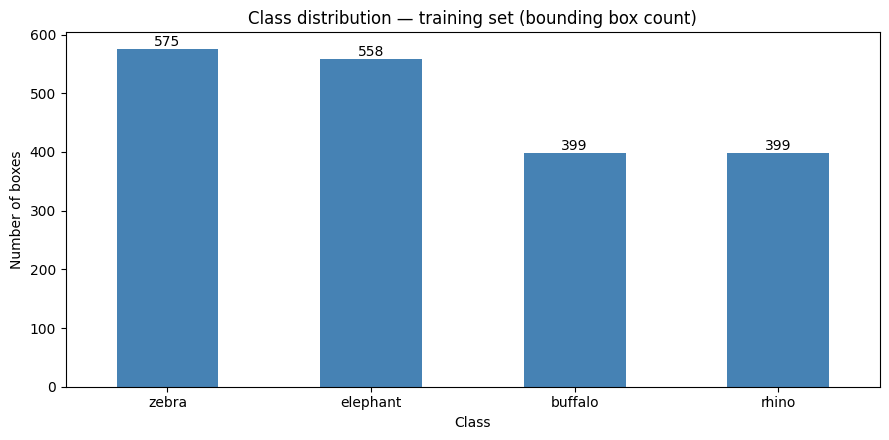


Hypothesis to verify after training:
  Best-performing class will likely be:  zebra (575 boxes)
  Worst-performing class will likely be: buffalo (399 boxes)


In [ ]:
def count_class_instances(labels_dir, class_names):
    """Count how many bounding boxes exist for each class across all label files in a directory.

    Note: we count BOXES (instances), not IMAGES. An image with 3 elephants in it contributes
    3 to the elephant count. That's the right unit for detection — the model is learning
    per-box, not per-image.
    """
    counter = Counter()
    for lp in glob.glob(str(labels_dir / '*.txt')):
        with open(lp) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    counter[int(parts[0])] += 1
    # Convert class_id -> class_name for readability
    return {class_names[k]: v for k, v in sorted(counter.items())}

train_dist = count_class_instances(train_labels_dir, CLASS_NAMES)
val_dist = count_class_instances(val_labels_dir, CLASS_NAMES)

dist_df = pd.DataFrame({'train': train_dist, 'val': val_dist}).fillna(0).astype(int)
dist_df['train_pct'] = (dist_df['train'] / dist_df['train'].sum() * 100).round(1)
dist_df = dist_df.sort_values('train', ascending=False)
print("Number of bounding boxes per class:\n")
print(dist_df)

# Plot it
fig, ax = plt.subplots(figsize=(9, 4.5))
dist_df['train'].plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Class distribution — training set (bounding box count)')
ax.set_ylabel('Number of boxes')
ax.set_xlabel('Class')
for i, v in enumerate(dist_df['train']):
    ax.text(i, v + 5, str(v), ha='center', fontsize=10)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Prediction time: which class do you expect the model to perform WORST on?
# (Hint: look at the shortest bar above. We'll come back and check after training.)
min_class = dist_df['train'].idxmin()
max_class = dist_df['train'].idxmax()
print(f"\nHypothesis to verify after training:")
print(f"  Best-performing class will likely be:  {max_class} ({dist_df.loc[max_class, 'train']} boxes)")
print(f"  Worst-performing class will likely be: {min_class} ({dist_df.loc[min_class, 'train']} boxes)")

---
## Section 7: Training — What We're Actually Doing




### Step 1: We load a COCO-pretrained YOLO model

```python
model = YOLO('yolov8n.pt')
```

This downloads ~6 MB of weights. These weights come from training on the COCO dataset — a massive, general-purpose dataset with 80 classes (person, car, dog, traffic light, etc.). 

So why bother with COCO-pretrained weights at all? Because the early layers of the CNN have already learned generic visual features — edges, textures, shapes, fur patterns, animal-ish structures. We get all of that "for free". We just need to teach the final layers our 4 specific classes.

This is **transfer learning**, and it's why detection training is tractable on 1000 images. From scratch, you'd need 100K+.

### Step 2: We call `model.train(...)`

When you call this, Ultralytics does a *lot* of things under the hood:

1. **Builds a dataloader** that reads images, applies augmentation (mosaic, hsv jitter, flip, scale), and batches them.
2. **Runs the forward pass**: image → backbone → neck → head → 3 multi-scale output tensors.
3. **Computes the three-part loss**: box regression (CIoU) + objectness (BCE) + classification (BCE).
4. **Backpropagates** and updates weights using AdamW or SGD (auto-selected).
5. **Uses mixed precision (AMP)** on GPU to halve memory usage and speed things up.
6. **Runs validation** at the end of every epoch and computes mAP.
7. **Saves checkpoints**: `best.pt` (best val mAP seen so far) and `last.pt` (most recent).
8. **Early-stops** if val mAP doesn't improve for `patience` epochs (prevents overfitting).
9. **Generates plots**: training curves, confusion matrix, PR curves.

All of that is hidden behind one function call. When you understand what's under the hood, you know what each output plot means and how to debug when something goes wrong.

### Hyperparameter choices

| Param | Value | Why |
|---|---|---|
| `model` | `yolov8n.pt` | Nano variant. Fast to train. 4 classes on 1000 images doesn't need more capacity. |
| `epochs` | 30 (GPU) / 10 (CPU) | Enough to converge on this small dataset. |
| `imgsz` | 640 | Standard. All images resized to 640x640 with letterbox padding. |
| `batch` | 16 | Fits on 8GB GPUs. Lower if you get OOM. |
| `patience` | 10 | Early stop if val mAP plateaus. |
| `seed` | 42 | Reproducibility. |

In [ ]:
# Instantiate the model. First run downloads ~6 MB from Ultralytics.
# We pick yolov8n (nano) — the smallest variant. Rule of thumb: start small, go bigger
# only if accuracy is insufficient. A bigger model is more often a painkiller than a cure.

model = YOLO('yolov8n.pt')

# Quick peek at what the pretrained model knows about out of the box
print(f"Task type:                  {model.task}")
print(f"Pretrained on N classes:    {len(model.names)}")
print(f"A few pretrained classes:   {list(model.names.values())[:15]}")
print(f"\nNote: the pretrained model knows 'zebra' and 'elephant' already (from COCO),")
print(f"but NOT 'buffalo' or 'rhino' as separate classes. Fine-tuning will teach it all 4.")

Task type:                  detect
Pretrained on N classes:    80
A few pretrained classes:   ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird']

Note: the pretrained model knows 'zebra' and 'elephant' already (from COCO),
but NOT 'buffalo' or 'rhino' as separate classes. Fine-tuning will teach it all 4.


In [ ]:
# ============================================================
#  TRAIN
# ============================================================
# A single function call that kicks off the entire training pipeline described above.
#
# On a T4 GPU (Colab free tier): ~15-20 min for 30 epochs.
# On CPU: ~1.5 hours for 10 epochs — reduced workload for tractability.

USE_GPU = torch.cuda.is_available()
device  = 0 if USE_GPU else 'cpu'
imgsz   = 640 if USE_GPU else 320   # smaller images on CPU to keep training bearable
epochs  = 30 if USE_GPU else 10
batch   = 16 if USE_GPU else 4

print(f"Training configuration:")
print(f"  device = {device}")
print(f"  imgsz  = {imgsz}")
print(f"  epochs = {epochs}")
print(f"  batch  = {batch}")
print(f"\nStarting training...\n")

results = model.train(
    data=str(LOCAL_YAML),       # our locally-written yaml with absolute paths
    epochs=epochs,
    imgsz=imgsz,
    batch=batch,
    device=device,
    patience=10,                 # early stop if no val mAP improvement for 10 epochs
    project='runs/wildlife',     # output directory for this experiment
    name='yolov8n_exp1',         # sub-directory name for this specific run
    exist_ok=True,               # overwrite on re-run
    seed=SEED,
    plots=True,                  # generate training plots automatically
    verbose=True,
    # --- Augmentation ---
    # The defaults are very good. 
    # mosaic=1.0       # 4 images stitched into one — the YOLO secret sauce
    # hsv_h=0.015      # hue jitter (trivial — just slight color shift)
    # hsv_s=0.7        # saturation jitter (more aggressive)
    # hsv_v=0.4        # value/brightness jitter
    # fliplr=0.5       # 50% probability of horizontal flip
    # degrees=0.0      # rotation (0 for most detection tasks — it breaks alignment)
)

print("\n" + "=" * 60)
print("Training complete!")
print("=" * 60)
print(f"Output directory:  {results.save_dir}")
print(f"Best weights:      {results.save_dir / 'weights' / 'best.pt'}")
print(f"Last weights:      {results.save_dir / 'weights' / 'last.pt'}")

Training configuration:
  device = 0
  imgsz  = 640
  epochs = 30
  batch  = 16

Starting training...

Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=african-wildlife-local.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov

---
## Section 8: Reading the Training Output

While training ran, you should have seen something like this scroll by:

```
Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances    Size
1/30     2.14G     1.489      3.205      1.432        42         640
2/30     2.14G     1.401      2.108      1.389        38         640
...
Class     Images    Inst      P         R         mAP50     mAP50-95
all       225       457       0.855     0.812     0.891     0.692
```

Let's decode what each column means. You should memorize this.

### Training columns (updated every batch, reported every epoch)

| Column | What it is | What "good" looks like |
|---|---|---|
| `box_loss` | CIoU loss. How wrong are our box coordinates? | Goes down smoothly. |
| `cls_loss` | BCE over class probabilities. Are we picking right class? | Goes down smoothly. |
| `dfl_loss` | Distribution Focal Loss — v8's refined box loss. | Goes down with box_loss. |
| `Instances` | How many ground-truth boxes in this batch | Varies per batch. |
| `Size` | Input image size (pixels) | Constant. |

### Validation columns (end of each epoch)

| Column | What it is | Typical value |
|---|---|---|
| `Images` | Number of val images used | = val set size |
| `Inst` | Number of ground truth boxes | Varies |
| `P` | Precision — of things we flagged, how many were right | 0.7-0.95 is decent |
| `R` | Recall — of things that existed, how many did we catch | 0.7-0.95 is decent |
| `mAP50` | mAP at IoU ≥ 0.5 (lenient) | 0.7+ is great |
| `mAP50-95` | mAP averaged across IoU 0.5–0.95 (strict, COCO style) | 0.4-0.6 is strong |

**Red flag patterns to watch for:**
- Train loss keeps dropping, val mAP plateaus or drops → **overfitting**
- Train loss plateaus early → **underfitting** (need more epochs or bigger model)
- `cls_loss` high while `box_loss` low → model finds objects but confuses classes
- `cls_loss` low while `box_loss` high → model classifies right but localizes poorly

Now let's look at the actual curves Ultralytics plotted for us automatically.

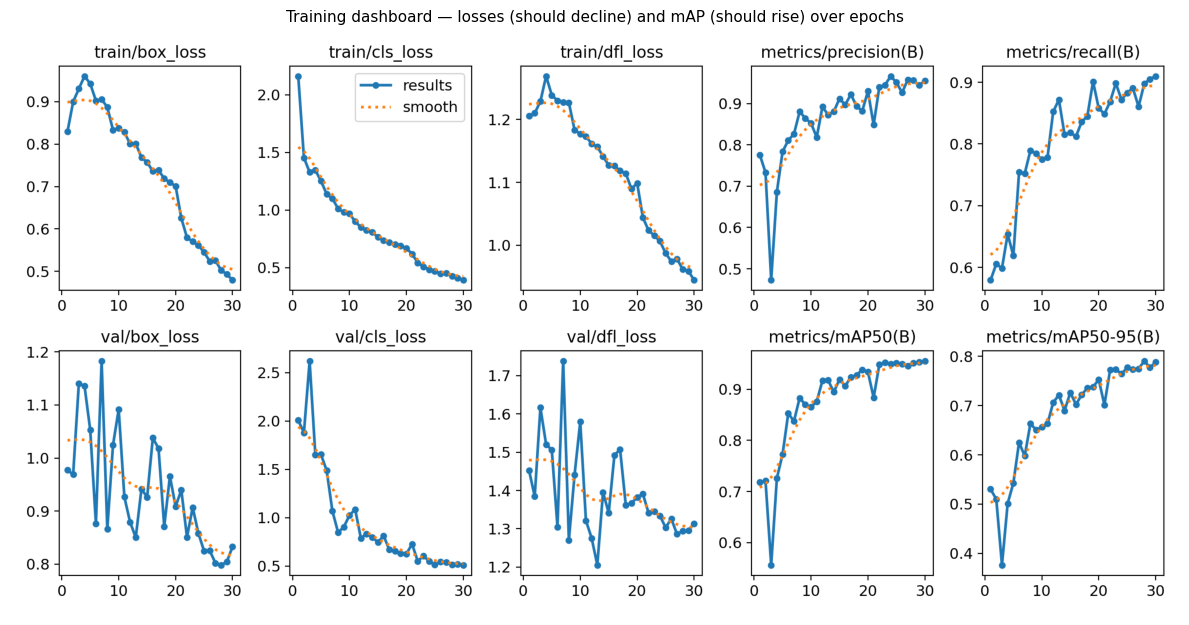

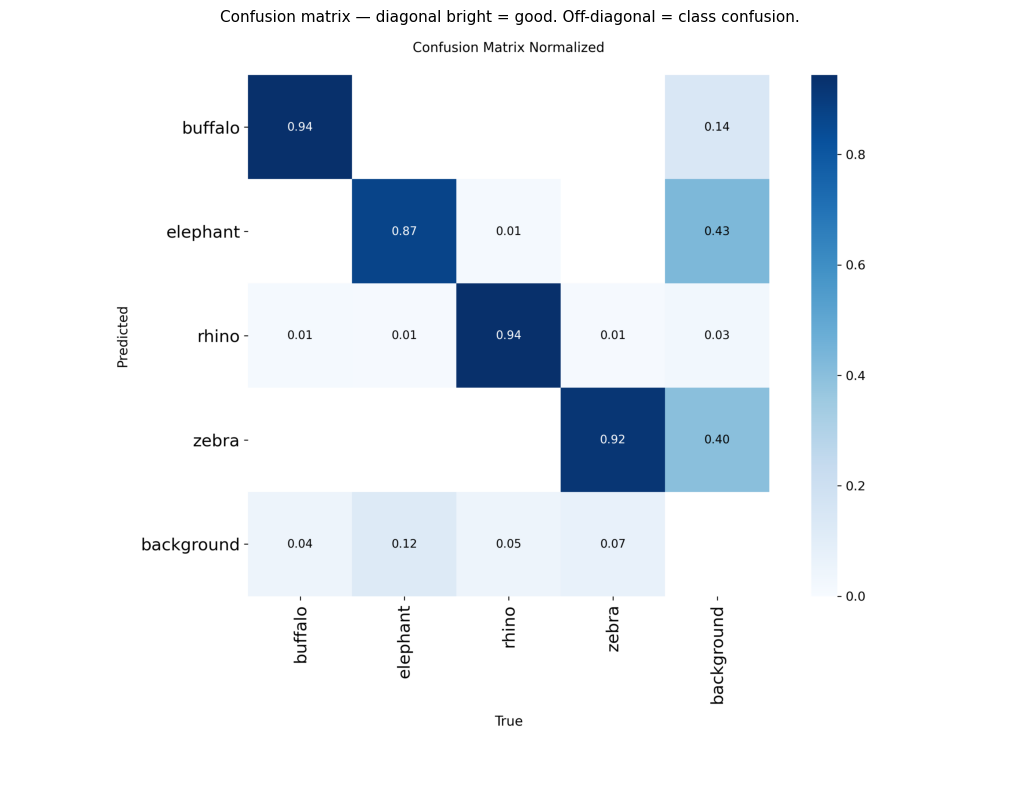

(Plot not found: /content/runs/detect/runs/wildlife/yolov8n_exp1/PR_curve.png — skipping)
(Plot not found: /content/runs/detect/runs/wildlife/yolov8n_exp1/F1_curve.png — skipping)


In [ ]:
# All the plots Ultralytics generated are in the run directory. Let's view them inline.
run_dir = Path('/content/runs/detect/runs/wildlife/yolov8n_exp1')

plots_to_show = [
    ('results.png',
     'Training dashboard — losses (should decline) and mAP (should rise) over epochs'),
    ('confusion_matrix_normalized.png',
     'Confusion matrix — diagonal bright = good. Off-diagonal = class confusion.'),
]

for fname, title in plots_to_show:
    path = run_dir / fname
    if path.exists():
        img = mpimg.imread(path)
        fig, ax = plt.subplots(figsize=(12, 8))
        ax.imshow(img)
        ax.set_title(title, fontsize=11)
        ax.axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print(f"(Plot not found: {path} — skipping)")

### How to read each of these plots

**results.png (the training dashboard)** — the single most important plot. It shows 10 subplots:
- Top row (training): `box_loss`, `cls_loss`, `dfl_loss`, `precision`, `recall`
- Bottom row (validation): same 5 metrics, computed on the held-out val set

The training and validation curves should **track each other**. If training loss keeps dropping but validation loss/mAP starts rising — that's overfitting, classic signature. With only 1000 images that's a realistic risk; the augmentation defaults prevent it in most cases.

**Confusion matrix (normalized)** — a grid where rows are *true* classes and columns are *predicted* classes. Diagonal = correct. Off-diagonal = confusion. Pay special attention to:
- `background` row/column: images that had objects we missed (false negatives, in the `background` column) or things we predicted where nothing was (false positives, in the `background` row).
- Class confusion pairs: if we're confusing buffalo with rhino, we might need more training data showing them side-by-side.

**PR curve** — one curve per class, plus the overall mean. If one class's curve lives close to the bottom-left corner, that class is performing poorly.

**F1 vs confidence threshold** — tells you what confidence threshold to use at deploy time. The peak of this curve is the F1-optimal threshold. The default `conf=0.25` is a reasonable starting point; you tune from there based on precision vs recall preference.

---
## Section 9: Evaluation — Numbers and Per-Class Breakdown

Now we load the best checkpoint and run it on the validation set to get **clean, reproducible metrics** separately from training. This also lets us look at per-class AP, which is the gold standard for diagnosing where our model is weak.

In [ ]:
# Load the 'best' checkpoint — the one with highest val mAP during training.
# 'last.pt' exists too but represents the state at end of training, which may not be the best.
best_weights = run_dir / 'weights' / 'best.pt'
best_model = YOLO(str(best_weights))

# model.val() runs full evaluation and returns a metrics object
metrics = best_model.val(
    data=str(LOCAL_YAML),
    imgsz=imgsz,
    device=device,
    split='val',
    plots=False,
    save_json=False,
    verbose=False,
)

# --- Headline numbers — this is what you'd put in a slide deck ---
print("=" * 60)
print("HEADLINE METRICS")
print("=" * 60)
print(f"mAP@0.5        : {metrics.box.map50:.4f}  (lenient — is the object detected at all?)")
print(f"mAP@0.5:0.95   : {metrics.box.map:.4f}  (strict — are the boxes tight?)")
print(f"Mean Precision : {metrics.box.mp:.4f}  (of things we flagged, how many right?)")
print(f"Mean Recall    : {metrics.box.mr:.4f}  (of things that existed, how many caught?)")
print("=" * 60)

# --- Per-class breakdown — this is where you spot the weak spots ---
print("\nPer-class performance (sorted by mAP@0.5:0.95):\n")
rows = []
for i, cname in CLASS_NAMES.items():
    try:
        ap = float(metrics.box.maps[i])
        rows.append({'class_id': i, 'class': cname, 'mAP_50_95': ap})
    except (IndexError, TypeError, KeyError):
        continue

per_class_df = pd.DataFrame(rows).sort_values('mAP_50_95', ascending=False)
print(per_class_df.to_string(index=False))

# Now verify our earlier hypothesis about class imbalance
print(f"\n--- Hypothesis check ---")
worst_class = per_class_df.iloc[-1]['class']
best_class = per_class_df.iloc[0]['class']
print(f"We predicted '{min_class}' would be worst → actual worst: '{worst_class}'")
print(f"We predicted '{max_class}' would be best  → actual best:  '{best_class}'")

Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1023.2±806.7 MB/s, size: 29.3 KB)
val: Scanning /content/datasets/african-wildlife/labels/val.cache... 225 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 225/225 72.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 5.4it/s 2.8s
                   all        225        379      0.938      0.918      0.951      0.792
Speed: 1.3ms preprocess, 5.8ms inference, 0.0ms loss, 1.9ms postprocess per image
HEADLINE METRICS
mAP@0.5        : 0.9514  (lenient — is the object detected at all?)
mAP@0.5:0.95   : 0.7917  (strict — are the boxes tight?)
Mean Precision : 0.9379  (of things we flagged, how many right?)
Mean Recall    : 0.9177  (of things that existed, how many caught?)

Per-class performance (sorted b



---
## Section 10: Inference — Seeing Predictions With Your Own Eyes

Metrics summarize everything into two or three numbers. That's useful for ranking models, but it hides important stuff. **Always look at actual predictions visually.**

This is the single habit that separates ML practitioners who catch bugs from those who ship them.

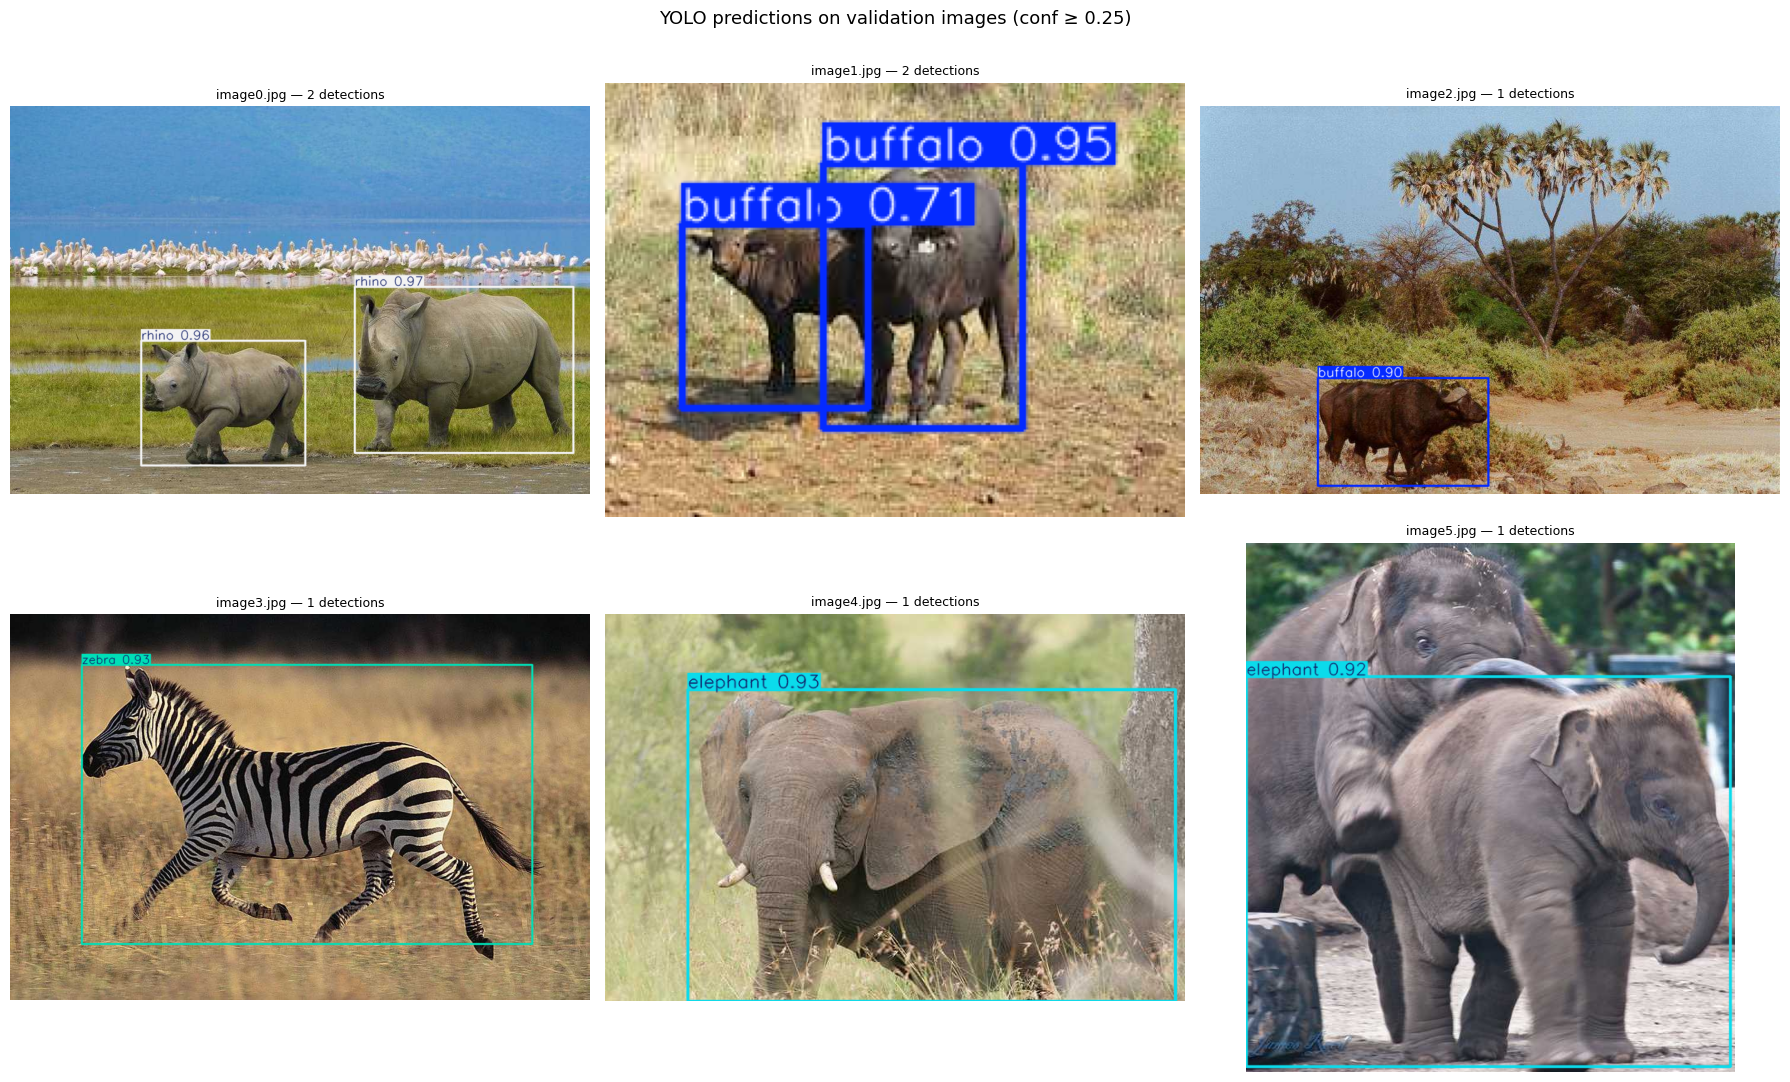

In [ ]:
# Predict on 6 random validation images.
# We use conf=0.25 (confidence threshold), which is a reasonable default.
# - Lower → more boxes, some wrong (higher recall, lower precision)
# - Higher → fewer boxes, mostly right (higher precision, lower recall)

random.seed(42)
sample_val_images = random.sample(val_images, min(6, len(val_images)))

results_inf = best_model.predict(
    sample_val_images,
    imgsz=imgsz,
    conf=0.25,   # confidence threshold
    iou=0.5,     # NMS IoU threshold
    device=device,
    verbose=False,
)

# The .plot() method returns a BGR numpy array of the image with boxes drawn.
# matplotlib expects RGB, so we flip the channel order with [..., ::-1].
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
for ax, res in zip(axes.flatten(), results_inf):
    annotated = res.plot()           # BGR array
    ax.imshow(annotated[..., ::-1])  # flip to RGB for matplotlib
    ax.axis('off')
    n_det = len(res.boxes) if res.boxes is not None else 0
    ax.set_title(f"{Path(res.path).name} — {n_det} detections", fontsize=9)

plt.suptitle("YOLO predictions on validation images (conf ≥ 0.25)", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Let's drill into ONE prediction to see the raw data structure that YOLO returns.
# This is what you'd iterate over in a production inference script.

r = results_inf[0]
print(f"Image path:        {r.path}")
print(f"Image shape (HWC): {r.orig_shape}")
print(f"Per-stage timing:  {r.speed}")
print()

if r.boxes is not None and len(r.boxes) > 0:
    print(f"{'idx':<4}{'class':<12}{'conf':<8}{'x1':<8}{'y1':<8}{'x2':<8}{'y2':<8}")
    print("-" * 60)
    for i, box in enumerate(r.boxes):
        cls_id = int(box.cls.item())
        cls_name = best_model.names[cls_id]
        conf = float(box.conf.item())
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        print(f"{i:<4}{cls_name:<12}{conf:<8.3f}{x1:<8.1f}{y1:<8.1f}{x2:<8.1f}{y2:<8.1f}")
else:
    print("(No detections — either image is empty, or conf threshold too high.)")

# This dict-of-tensors is what feeds into your app logic in production:
#   'if any detection has cls=2 (rhino) with conf > 0.6, log it and alert rangers'

Image path:        image0.jpg
Image shape (HWC): (619, 926)
Per-stage timing:  {'preprocess': 1.9749786667186224, 'inference': 6.746626500065152, 'postprocess': 0.8608226667092822}

idx class       conf    x1      y1      x2      y2      
------------------------------------------------------------
0   rhino       0.974   550.3   288.2   899.5   553.9   
1   rhino       0.961   209.5   374.8   471.5   573.4   


---
## Section 11: Exporting to ONNX for Deployment

Training a model is maybe 10% of an ML product's lifetime. The other 90% is **deployment**. For that, we export the model to a format that runs outside PyTorch.

**ONNX (Open Neural Network Exchange)** is the universal interchange format. It's supported by:
- ONNX Runtime (CPU and GPU, x86 and ARM)
- NVIDIA TensorRT (via ONNX conversion)
- Mobile runtimes (CoreML, NNAPI)
- Embedded accelerators (Jetson, Intel NPU, Samsung NPU)

The general deployment pipeline for edge / mobile devices is:

```
   PyTorch (.pt)  →  ONNX (.onnx)  →  INT8 quantized  →  target runtime
```

In [ ]:
# Export the trained model to ONNX. Ultralytics handles:
#   - Tracing the PyTorch graph
#   - Embedding preprocessing/postprocessing appropriately
#   - Writing metadata (class names, input shapes)
#   - Simplifying the graph with onnx-simplifier

onnx_path = best_model.export(
    format='onnx',
    imgsz=imgsz,
    opset=12,       # ONNX opset version. 12 is a safe, widely-compatible choice.
    simplify=True,  # clean up the graph for faster inference
    dynamic=False,  # fixed input shape. Required for some accelerators (TensorRT, NPUs).
)

onnx_size_mb = Path(onnx_path).stat().st_size / 1e6
print(f"\nONNX model saved:  {onnx_path}")
print(f"File size:         {onnx_size_mb:.2f} MB")
print(f"\nAt deployment time, you'd typically:")
print(f"  1. Quantize this FP32 model to INT8 (→ ~{onnx_size_mb/4:.1f} MB, ~3-5x faster on CPU)")
print(f"  2. Validate accuracy hasn't dropped more than ~2% after quantization")
print(f"  3. Run through your target runtime (ONNX Runtime, TensorRT, NNAPI, ...)")

In [ ]:
# Sanity-check the ONNX model by running the same prediction and comparing to PyTorch.
# In production, this equivalence check is MANDATORY — quantization and graph
# simplification can introduce subtle bugs.

onnx_model = YOLO(str(onnx_path))  # Ultralytics wraps ONNX Runtime internally

test_img = val_images[0]
pt_result = best_model.predict(test_img, conf=0.25, verbose=False)[0]
onnx_result = onnx_model.predict(test_img, conf=0.25, verbose=False)[0]

pt_n = len(pt_result.boxes) if pt_result.boxes is not None else 0
onnx_n = len(onnx_result.boxes) if onnx_result.boxes is not None else 0

print(f"Equivalence check on: {Path(test_img).name}")
print(f"  PyTorch detections: {pt_n}")
print(f"  ONNX detections:    {onnx_n}")
if pt_n == onnx_n:
    print(f"  → MATCH. Export is healthy.")
else:
    print(f"  → MISMATCH. Investigate before shipping.")

# Side-by-side visual check
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(pt_result.plot()[..., ::-1])
axes[0].set_title(f"PyTorch (.pt) — {pt_n} detections")
axes[0].axis('off')
axes[1].imshow(onnx_result.plot()[..., ::-1])
axes[1].set_title(f"ONNX — {onnx_n} detections")
axes[1].axis('off')
plt.tight_layout()
plt.show()


## Section 12: Recap — What You Just Did

In this notebook you:

1. Auto-downloaded a 100 MB public dataset (no API keys).
2. Read a real YOLO label file and converted its numbers to pixel boxes by hand.
3. Visualized the training images, checked class balance, formed a hypothesis.
4. Fine-tuned a COCO-pretrained YOLOv8n model (30 epochs or 10 on CPU).
5. Read training curves, per-class AP, confusion matrix, PR curves.
6. Ran inference and inspected predictions both visually and structurally.
7. Wrapped the model in a "wildlife sighting logger" application.
8. Exported to ONNX and verified PyTorch ↔ ONNX equivalence.

This is the complete real-world workflow, compressed. Everything else you'll encounter is scale, domain-specific tweaks, or MLOps polish.

---